In [1]:
#Importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression

In [ ]:
#Cargar base TOPS TDH
df_tops = pd.read_csv('Analisis GAC Full7agosto 2026(TOPS TDH).csv')

In [6]:
#Revisar la estructura completa de la base de forma vertical
df_tops.head().T

,0,1,2,3,4
INDICADORES GENERALES,NaN,NaN,Mes,Plantilla,Operando
Unnamed: 1,NaN,2025,Enero,29,28
Unnamed: 2,NaN,NaN,Febrero,29,24
Unnamed: 3,NaN,NaN,Marzo,29,26
Unnamed: 4,NaN,NaN,Abril,30,27
Unnamed: 5,NaN,NaN,Mayo,31,28
Unnamed: 6,NaN,NaN,Junio,33,29
Unnamed: 7,NaN,NaN,Julio,33,30
Unnamed: 8,NaN,NaN,Agosto,34,32
Unnamed: 9,NaN,NaN,Septiembre,35,34


In [7]:
#Extraer los datos útiles de Mes, Plantilla y Operando
tops_limpio = df_tops.iloc[2:5, 1:20].T

#Asignar nombres a las columnas
tops_limpio.columns = ['Mes', 'Plantilla', 'Operando']

#Reiniciar índices
tops_limpio = tops_limpio.reset_index(drop=True)

tops_limpio

,Mes,Plantilla,Operando
0,Enero,29,28
1,Febrero,29,24
2,Marzo,29,26
3,Abril,30,27
4,Mayo,31,28
5,Junio,33,29
6,Julio,33,30
7,Agosto,34,32
8,Septiembre,35,34
9,Octubre,36,34


In [8]:
#Agregar el año correspondiente
tops_limpio['Año'] = [2025] * 12 + [2026] * 7

#Ordenar las columnas
tops_limpio = tops_limpio[['Año', 'Mes', 'Plantilla', 'Operando']]

tops_limpio

,Año,Mes,Plantilla,Operando
0,2025,Enero,29,28
1,2025,Febrero,29,24
2,2025,Marzo,29,26
3,2025,Abril,30,27
4,2025,Mayo,31,28
5,2025,Junio,33,29
6,2025,Julio,33,30
7,2025,Agosto,34,32
8,2025,Septiembre,35,34
9,2025,Octubre,36,34


In [ ]:
#Convertir las variables a tipo numérico
tops_limpio['Plantilla'] = pd.to_numeric(tops_limpio['Plantilla'])
tops_limpio['Operando'] = pd.to_numeric(tops_limpio['Operando'])

tops_limpio.info()


<class 'pandas.DataFrame'>
RangeIndex: 19 entries, 0 to 18
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Año        19 non-null     int64
 1   Mes        19 non-null     str  
 2   Plantilla  19 non-null     int64
 3   Operando   19 non-null     int64
dtypes: int64(3), str(1)
memory usage: 740.0 bytes


In [10]:
#Revisar valores nulos
tops_limpio.isnull().sum()

Año          0
Mes          0
Plantilla    0
Operando     0
dtype: int64

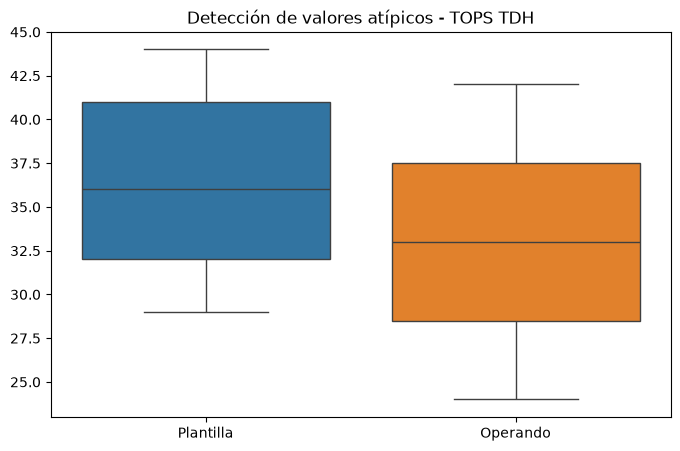

In [11]:
#Revisar posibles valores atípicos
plt.figure(figsize=(8, 5))

sns.boxplot(data=tops_limpio[['Plantilla', 'Operando']])

plt.title('Detección de valores atípicos - TOPS TDH')
plt.show()

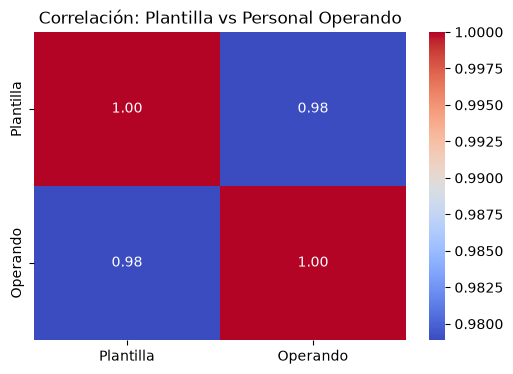

In [12]:
#Mapa de calor de correlación
correlacion_tops_matriz = tops_limpio[['Plantilla', 'Operando']].corr()

plt.figure(figsize=(6, 4))

sns.heatmap(
    correlacion_tops_matriz,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlación: Plantilla vs Personal Operando')
plt.show()

In [13]:
#Definir variable independiente y dependiente
X_tops = tops_limpio[['Plantilla']]
y_tops = tops_limpio['Operando']

In [14]:
#Crear y entrenar el modelo de Regresión Lineal Simple
modelo_tops = LinearRegression()

modelo_tops.fit(X_tops, y_tops)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[0.98]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Plantilla']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-2.405
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [15]:
#Obtener resultados del modelo
print('Pendiente:', modelo_tops.coef_[0])
print('Intercepto:', modelo_tops.intercept_)
print('R cuadrada:', modelo_tops.score(X_tops, y_tops))

Pendiente: 0.984984399375975
Intercepto: -2.405226209048365
R cuadrada: 0.9582350156487


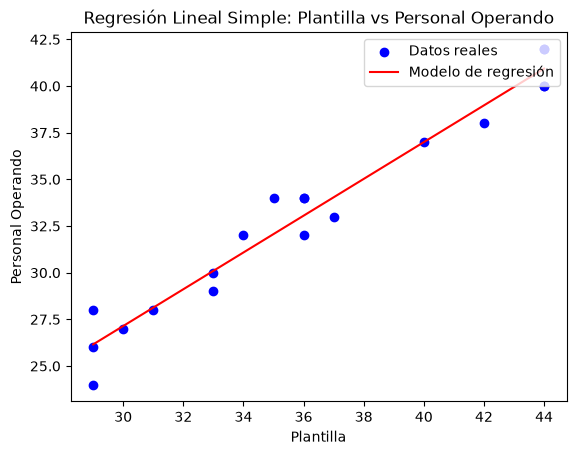

In [52]:
plt.scatter(
    tops_limpio['Plantilla'],
    tops_limpio['Operando'],
    color='blue',
    label='Datos reales'
)

plt.plot(
    tops_limpio['Plantilla'],
    modelo_tops.predict(X_tops),
    color='red',
    label='Modelo de regresión'
)

plt.xlabel('Plantilla')
plt.ylabel('Personal Operando')
plt.title('Regresión Lineal Simple: Plantilla vs Personal Operando')

plt.legend(loc='upper right')

plt.show()

In [17]:
#Cargar base Resumen
df_resumen = pd.read_csv('Analisis GAC Full7agosto 2026(Resumen).csv')

In [19]:
#Revisar la estructura de la base
df_resumen.head()

,RESUMEN AL CUMPLIMIENTO DE OBJETIVOS,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 51,Unnamed: 52,Unnamed: 53,Unnamed: 54,Unnamed: 55,Unnamed: 56,Unnamed: 57,Unnamed: 58,Unnamed: 59,Unnamed: 60
0,Resumen de Operaciones\nDto. Autos Nuevos,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,Promedio Mes,"1,109",653,27,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,"33,275","19,582",822,NaN,833,NaN,NaN,4.43%,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Año,Mes,Leads,Efectivos,Ventas Reportadas,Obj Ventas,Ventas Real,% CAL,Obj Conversion,Conversion,...,NaN,NaN,NaN,NaN,NaN,Proyeccion,Diferencia,NaN,NaN,NaN


In [18]:
#Revisar la estructura completa de forma vertical
df_resumen.head().T

,0,1,2,3,4
RESUMEN AL CUMPLIMIENTO DE OBJETIVOS,Resumen de Operaciones\nDto. Autos Nuevos,NaN,NaN,NaN,Año
Unnamed: 1,NaN,Promedio Mes,NaN,NaN,Mes
Unnamed: 2,NaN,"1,109",NaN,"33,275",Leads
Unnamed: 3,NaN,653,NaN,"19,582",Efectivos
Unnamed: 4,NaN,27,NaN,822,Ventas Reportadas
...,...,...,...,...,...
Unnamed: 56,NaN,NaN,NaN,NaN,Proyeccion
Unnamed: 57,NaN,NaN,NaN,NaN,Diferencia
Unnamed: 58,NaN,NaN,NaN,NaN,NaN
Unnamed: 59,NaN,NaN,NaN,NaN,NaN


In [20]:
#Extraer los datos necesarios de la base Resumen
resumen_limpio = df_resumen.iloc[5:35, 0:4].copy()

#Asignar nombres a las columnas
resumen_limpio.columns = ['Año', 'Mes', 'Leads', 'Efectivos']

#Reiniciar índices
resumen_limpio = resumen_limpio.reset_index(drop=True)

resumen_limpio

,Año,Mes,Leads,Efectivos
0,2024,Febrero,543,389
1,NaN,Marzo,178,128
2,NaN,Abril,416,288
3,NaN,Mayo,422,274
4,NaN,Junio,967,620
5,NaN,Julio,954,570
6,NaN,Agosto,"1,409",546
7,NaN,Septiembre,"1,315",530
8,NaN,Octubre,"1,973",822
9,NaN,Noviembre,"1,562","1,040"


In [21]:
#Completar los valores del Año
resumen_limpio['Año'] = resumen_limpio['Año'].ffill()

#Convertir Año a entero
resumen_limpio['Año'] = resumen_limpio['Año'].astype(int)

resumen_limpio

,Año,Mes,Leads,Efectivos
0,2024,Febrero,543,389
1,2024,Marzo,178,128
2,2024,Abril,416,288
3,2024,Mayo,422,274
4,2024,Junio,967,620
5,2024,Julio,954,570
6,2024,Agosto,"1,409",546
7,2024,Septiembre,"1,315",530
8,2024,Octubre,"1,973",822
9,2024,Noviembre,"1,562","1,040"


In [22]:
#Convertir Leads y Efectivos a tipo numérico
resumen_limpio['Leads'] = pd.to_numeric(
    resumen_limpio['Leads'].astype(str).str.replace(',', ''),
    errors='coerce'
)

resumen_limpio['Efectivos'] = pd.to_numeric(
    resumen_limpio['Efectivos'].astype(str).str.replace(',', ''),
    errors='coerce'
)

resumen_limpio.info()

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Año        30 non-null     int64
 1   Mes        30 non-null     str  
 2   Leads      30 non-null     int64
 3   Efectivos  30 non-null     int64
dtypes: int64(3), str(1)
memory usage: 1.1 KB


In [23]:
#Revisar valores nulos
resumen_limpio.isnull().sum()

Año          0
Mes          0
Leads        0
Efectivos    0
dtype: int64

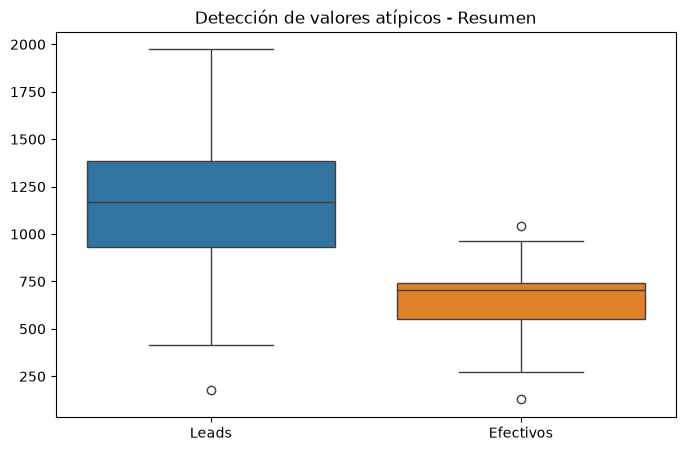

In [24]:
#Revisar posibles valores atípicos
plt.figure(figsize=(8, 5))

sns.boxplot(data=resumen_limpio[['Leads', 'Efectivos']])

plt.title('Detección de valores atípicos - Resumen')
plt.show()

In [25]:
#Calcular correlación entre Efectivos y Total de Leads
correlacion_resumen = resumen_limpio['Efectivos'].corr(
    resumen_limpio['Leads']
)

print('Correlación:', correlacion_resumen)

Correlación: 0.8091031764826592


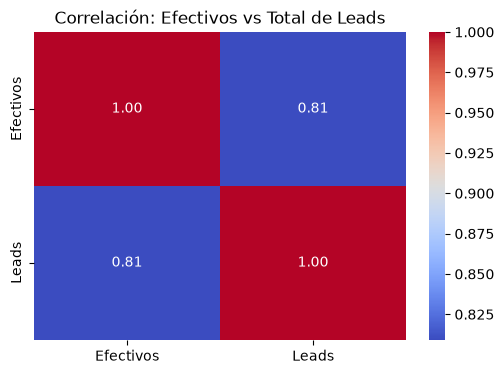

In [26]:
#Mapa de calor de correlación
correlacion_resumen_matriz = resumen_limpio[
    ['Efectivos', 'Leads']
].corr()

plt.figure(figsize=(6, 4))

sns.heatmap(
    correlacion_resumen_matriz,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlación: Efectivos vs Total de Leads')
plt.show()

In [27]:
#Definir variable independiente y dependiente
X_resumen = resumen_limpio[['Efectivos']]
y_resumen = resumen_limpio['Leads']

In [28]:
#Crear y entrenar el modelo de Regresión Lineal Simple
modelo_resumen = LinearRegression()

modelo_resumen.fit(X_resumen, y_resumen)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[1.58]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Efectivos']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,75.28
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [29]:
#Obtener resultados del modelo
print('Pendiente:', modelo_resumen.coef_[0])
print('Intercepto:', modelo_resumen.intercept_)
print('R cuadrada:', modelo_resumen.score(X_resumen, y_resumen))

Pendiente: 1.5839410766573414
Intercepto: 75.27552789653146
R cuadrada: 0.6546479501943294


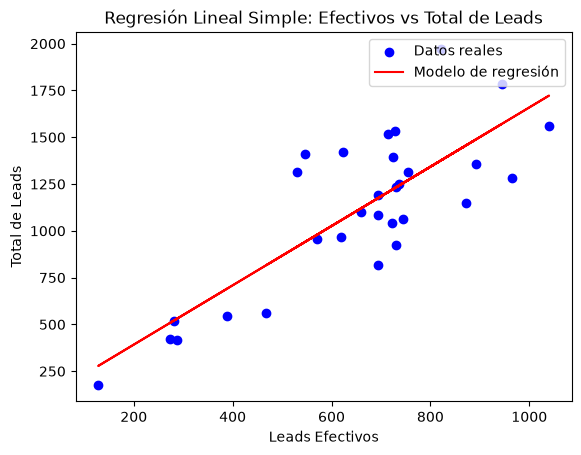

In [53]:
plt.scatter(
    resumen_limpio['Efectivos'],
    resumen_limpio['Leads'],
    color='blue',
    label='Datos reales'
)

plt.plot(
    resumen_limpio['Efectivos'],
    modelo_resumen.predict(X_resumen),
    color='red',
    label='Modelo de regresión'
)

plt.xlabel('Leads Efectivos')
plt.ylabel('Total de Leads')
plt.title('Regresión Lineal Simple: Efectivos vs Total de Leads')

plt.legend(loc='upper right')

plt.show()

In [32]:
#Cargar base MKT Digital
df_mkt = pd.read_csv('Analisis GAC Full7agosto 2026(MKT Digital ).csv')

In [33]:
#Revisar las primeras filas
df_mkt.head()

,Nov-25,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 38,Unnamed: 39,Unnamed: 40,Unnamed: 41,Unnamed: 42,Unnamed: 43,Unnamed: 44,Unnamed: 45,Unnamed: 46,Unnamed: 47
0,NaN,1RA SEMANA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,1,2,3,4,5,6,7,NaN,NaN,...,29,30.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,CAMPAÑA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,FORMULARIO ANGELÓPOLIS,6,5,5,2,6,3,4,FORMULARIOS,31.0,...,2,4.0,FORMULARIOS,19,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [34]:
#Revisar la estructura completa de forma vertical
df_mkt.head().T

,0,1,2,3,4
Nov-25,NaN,NaN,CAMPAÑA,FORMULARIO ANGELÓPOLIS,NaN
Unnamed: 1,1RA SEMANA,1,NaN,6,NaN
Unnamed: 2,NaN,2,NaN,5,NaN
Unnamed: 3,NaN,3,NaN,5,NaN
Unnamed: 4,NaN,4,NaN,2,NaN
Unnamed: 5,NaN,5,NaN,6,NaN
Unnamed: 6,NaN,6,NaN,3,NaN
Unnamed: 7,NaN,7,NaN,4,NaN
Unnamed: 8,NaN,NaN,NaN,FORMULARIOS,NaN
Unnamed: 9,NaN,NaN,NaN,31.0,NaN


In [37]:
#Extraer Día de campaña y Leads

datos_mkt = []

for columna in df_mkt.columns:
    
    dia = pd.to_numeric(df_mkt.loc[1, columna], errors='coerce')
    leads = pd.to_numeric(df_mkt.loc[3, columna], errors='coerce')
    
    if pd.notna(dia) and pd.notna(leads):
        datos_mkt.append([int(dia), int(leads)])

mkt_limpio = pd.DataFrame(
    datos_mkt,
    columns=['Dia', 'Leads']
)

mkt_limpio

,Dia,Leads
0,1,6
1,2,5
2,3,5
3,4,2
4,5,6
5,6,3
6,7,4
7,8,10
8,9,4
9,10,5


In [38]:
#Revisar información de la base
mkt_limpio.info()

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Dia     30 non-null     int64
 1   Leads   30 non-null     int64
dtypes: int64(2)
memory usage: 612.0 bytes


In [39]:
#Revisar valores nulos
mkt_limpio.isnull().sum()

Dia      0
Leads    0
dtype: int64

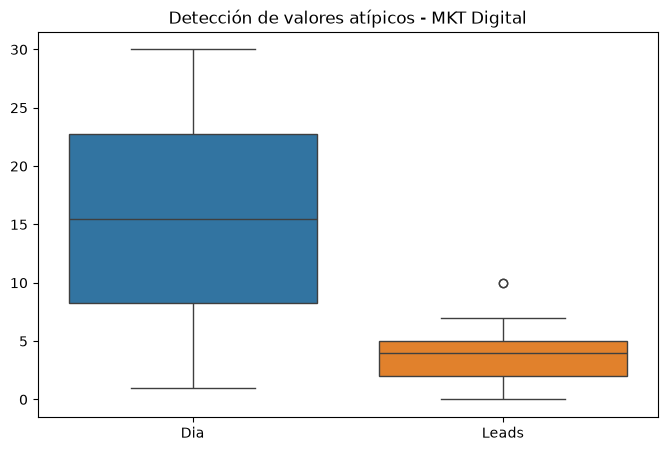

In [40]:
#Revisar posibles valores atípicos
plt.figure(figsize=(8, 5))

sns.boxplot(data=mkt_limpio[['Dia', 'Leads']])

plt.title('Detección de valores atípicos - MKT Digital')
plt.show()

In [41]:
#Calcular correlación entre Día de campaña y Leads
correlacion_mkt = mkt_limpio['Dia'].corr(
    mkt_limpio['Leads']
)

print('Correlación:', correlacion_mkt)

Correlación: -0.43012450965482873


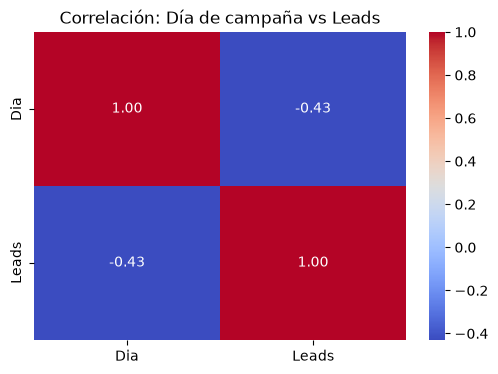

In [42]:
#Mapa de calor de correlación
correlacion_mkt_matriz = mkt_limpio[
    ['Dia', 'Leads']
].corr()

plt.figure(figsize=(6, 4))

sns.heatmap(
    correlacion_mkt_matriz,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlación: Día de campaña vs Leads')
plt.show()

In [43]:
#Definir variable independiente y dependiente
X_mkt = mkt_limpio[['Dia']]
y_mkt = mkt_limpio['Leads']

In [44]:
#Crear y entrenar el modelo de Regresión Lineal Simple
modelo_mkt = LinearRegression()

modelo_mkt.fit(X_mkt, y_mkt)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[-0.12]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Dia']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,5.651
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [45]:
#Obtener resultados del modelo
print('Pendiente:', modelo_mkt.coef_[0])
print('Intercepto:', modelo_mkt.intercept_)
print('R cuadrada:', modelo_mkt.score(X_mkt, y_mkt))

Pendiente: -0.1236929922135706
Intercepto: 5.650574712643678
R cuadrada: 0.18500709380580704


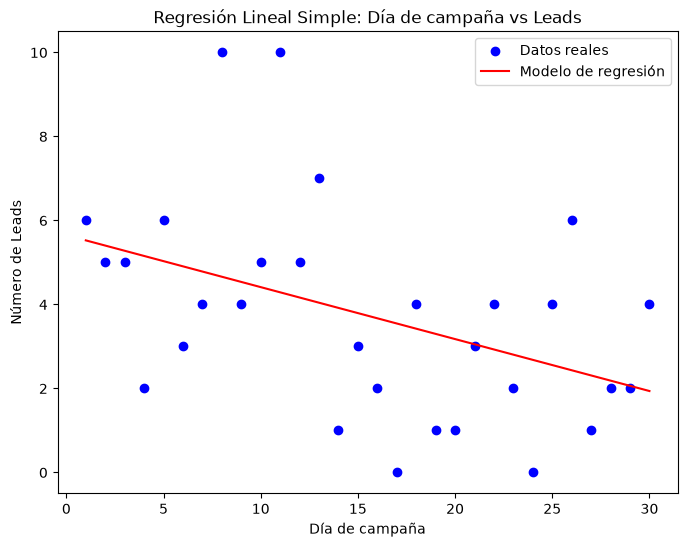

In [51]:
#Gráfica de Regresión Lineal Simple

plt.figure(figsize=(8, 6))

plt.scatter(
    mkt_limpio['Dia'],
    mkt_limpio['Leads'],
    color='blue',
    label='Datos reales'
)

plt.plot(
    mkt_limpio['Dia'],
    modelo_mkt.predict(X_mkt),
    color='red',
    label='Modelo de regresión'
)

plt.xlabel('Día de campaña')
plt.ylabel('Número de Leads')
plt.title('Regresión Lineal Simple: Día de campaña vs Leads')

plt.legend(loc='upper right')

plt.show()